In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [ ]:
session_day_df

In [9]:
import numpy as np
import pandas as pd


def make_habituation_session_summary(
    encoder_epoch_df,
    metrics=None,
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
):
    """
    Make one row per animal/date for habituation/repeated wheel exposure.

    This summarizes available epoch windows within each session.
    """

    if metrics is None:
        metrics = [
            "frac_forward",
            "frac_stationary",
            "frac_moving",
            "mean_speed_path_cms",
            "mean_speed_net_cms",
        ]

    df = encoder_epoch_df.copy()

    df = df[df["phase"] == "habituation"].copy()

    if require_good_session and "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if require_valid_window and "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    metrics = [m for m in metrics if m in df.columns]

    id_cols = [
        "animal",
        "date",
        "phase",
        "phase_day_from_date",
        "phase_session_number",
        "phase_session_start_min",
        "rig_session_number",
        "rig_session_start_min",
        "recording_duration_min",
    ]

    id_cols = [c for c in id_cols if c in df.columns]

    agg_dict = {m: (m, "mean") for m in metrics}
    agg_dict.update({
        "n_windows": ("epoch_name", "count"),
        "n_anchors": ("anchor_name", "nunique"),
    })

    session_df = (
        df
        .groupby(id_cols, observed=False)
        .agg(**agg_dict)
        .reset_index()
        .sort_values(["animal", "phase_session_number"])
        .reset_index(drop=True)
    )

    return session_df


hab_session_df = make_habituation_session_summary(encoder_epoch_df)
hab_session_df.head()

,animal,date,phase,phase_day_from_date,phase_session_number,phase_session_start_min,rig_session_number,rig_session_start_min,recording_duration_min,frac_forward,frac_stationary,frac_moving,mean_speed_path_cms,mean_speed_net_cms,n_windows,n_anchors
0,NML_04,2025_12_27,habituation,1,1,0.000000,1,0.000000,21.846667,0.193729,0.642849,0.357151,0.798838,0.096692,503,6
1,NML_04,2025_12_28,habituation,2,2,21.846667,2,21.846667,24.556667,0.162599,0.704591,0.295409,0.540097,0.074092,516,6
2,NML_04,2025_12_29,habituation,3,3,46.403333,3,46.403333,20.908333,0.230797,0.661419,0.338581,0.688970,0.355807,492,6
3,NML_04,2025_12_30,habituation,4,4,67.311667,4,67.311667,27.070000,0.264549,0.667741,0.332259,0.912839,0.713102,636,6
4,NML_04,2025_12_31,habituation,5,5,94.381667,5,94.381667,22.110000,0.277843,0.677627,0.322373,0.927110,0.811146,492,6


In [10]:
def estimate_minimum_stable_session(
    session_df,
    outcome="frac_forward",
    session_col="phase_session_number",
    animal_col="animal",
    last_n_reference=3,
    tolerance=0.05,
    require_all_future=True,
):
    """
    Estimate earliest session where group mean is close to the late-session reference.

    For fraction outcomes, tolerance can be absolute, e.g. ±0.05.
    """

    df = session_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    # Late reference per animal = mean of last N sessions for that animal
    late_ref = (
        df.sort_values([animal_col, session_col])
        .groupby(animal_col)
        .tail(last_n_reference)
        .groupby(animal_col)[outcome]
        .mean()
        .reset_index(name=f"{outcome}_late_ref")
    )

    df = df.merge(late_ref, on=animal_col, how="left")

    df["abs_diff_from_late_ref"] = (
        df[outcome] - df[f"{outcome}_late_ref"]
    ).abs()

    # Group-level summary by session
    group_df = (
        df
        .groupby(session_col)
        .agg(
            mean_outcome=(outcome, "mean"),
            sem_outcome=(outcome, lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            mean_abs_diff=("abs_diff_from_late_ref", "mean"),
            max_abs_diff=("abs_diff_from_late_ref", "max"),
            n_animals=(animal_col, "nunique"),
        )
        .reset_index()
    )

    group_df["within_tolerance_mean"] = (
        group_df["mean_abs_diff"] <= tolerance
    )

    group_df["within_tolerance_all_animals"] = (
        group_df["max_abs_diff"] <= tolerance
    )

    # Choose criterion
    criterion_col = (
        "within_tolerance_all_animals"
        if require_all_future
        else "within_tolerance_mean"
    )

    candidate_sessions = []

    for s in sorted(group_df[session_col].unique()):
        future = group_df[group_df[session_col] >= s]

        if future[criterion_col].all():
            candidate_sessions.append(s)

    min_session = candidate_sessions[0] if len(candidate_sessions) > 0 else np.nan

    return min_session, group_df, df

In [11]:
outcomes = [
    ("frac_forward", 0.05),
    ("frac_stationary", 0.05),
    ("frac_moving", 0.05),
    ("mean_speed_path_cms", 0.50),  # example absolute cm/s tolerance
    ("mean_speed_net_cms", 0.50),
]

minimum_rows = []

for outcome, tol in outcomes:
    min_session, group_df, detail_df = estimate_minimum_stable_session(
        hab_session_df,
        outcome=outcome,
        last_n_reference=3,
        tolerance=tol,
        require_all_future=False,  # group-level criterion first
    )

    minimum_rows.append({
        "outcome": outcome,
        "tolerance": tol,
        "estimated_minimum_session": min_session,
    })

minimum_summary_df = pd.DataFrame(minimum_rows)
minimum_summary_df

,outcome,tolerance,estimated_minimum_session
0,frac_forward,0.05,19
1,frac_stationary,0.05,19
2,frac_moving,0.05,19
3,mean_speed_path_cms,0.50,18
4,mean_speed_net_cms,0.50,18


In [12]:
import statsmodels.formula.api as smf


def fit_habituation_lme(session_df, outcome):
    df = session_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    df["phase_session_c"] = (
        df["phase_session_number"] - df["phase_session_number"].mean()
    )

    model = smf.mixedlm(
        f"{outcome} ~ phase_session_c",
        data=df,
        groups=df["animal"],
        re_formula="1",
    ).fit(
        reml=False,
        method="lbfgs",
        maxiter=1000,
    )

    return model


m_hab_forward = fit_habituation_lme(hab_session_df, "frac_forward")
m_hab_stationary = fit_habituation_lme(hab_session_df, "frac_stationary")
m_hab_speed = fit_habituation_lme(hab_session_df, "mean_speed_path_cms")

print(m_hab_forward.summary())
print(m_hab_stationary.summary())
print(m_hab_speed.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_forward
No. Observations: 85      Method:             ML          
No. Groups:       5       Scale:              0.0195      
Min. group size:  16      Log-Likelihood:     38.5794     
Max. group size:  19      Converged:          Yes         
Mean group size:  17.0                                    
----------------------------------------------------------
                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.258    0.077 3.338 0.001  0.107  0.409
phase_session_c   0.021    0.003 6.909 0.000  0.015  0.027
Group Var         0.029    0.139                          

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_stationary
No. Observations: 85      Method:             ML             
No. Groups:       5       Scale:              0.0208         
Min. gr

In [15]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_summary_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_df.head()



,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,median_speed_net_cms,min_speed_net_cms,max_speed_net_cms,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.0,-11.812388,13.320353,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.0,-11.058406,9.299114,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.0,-10.304424,11.561061,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.0,-7.539822,14.325663,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.0,-7.791150,13.823008,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok


In [16]:
hab_df[
    [
        "animal",
        "date",
        "phase_session_number",
        "duration_min_used",
        "total_distance_path_cm",
        "distance_path_per_min",
        "total_distance_net_cm",
        "distance_net_per_min",
        "frac_forward",
        "frac_stationary",
        "mean_speed_path_cms",
        "mean_speed_net_cms",
        "status_whole_session",
    ]
].head(30)

,animal,date,phase_session_number,duration_min_used,total_distance_path_cm,distance_path_per_min,total_distance_net_cm,distance_net_per_min,frac_forward,frac_stationary,mean_speed_path_cms,mean_speed_net_cms,status_whole_session
0,NML_04,2025_12_27,1,21.846667,1054.343627,48.261075,158.813792,7.269475,0.190179,0.652482,0.783014,0.121107,ok
1,NML_04,2025_12_28,2,24.556667,899.500809,36.629597,100.581230,4.095883,0.169932,0.688418,0.592844,0.068305,ok
2,NML_04,2025_12_29,3,20.908333,906.839569,43.372160,484.257658,23.160988,0.245342,0.647617,0.706021,0.386026,ok
3,NML_04,2025_12_30,4,27.070000,1498.011908,55.338452,1163.444857,42.979123,0.268207,0.664122,0.910905,0.716319,ok
4,NML_04,2025_12_31,5,22.110000,1152.989637,52.147880,946.549300,42.810914,0.254244,0.695495,0.859619,0.713525,ok
5,NML_04,2026_01_01,6,22.351667,1630.813313,72.961598,1354.051566,60.579445,0.277959,0.658814,1.209258,1.009552,ok
6,NML_04,2026_01_02,7,20.680000,1439.075630,69.587796,1210.216888,58.521126,0.295635,0.637711,1.152552,0.975350,ok
7,NML_04,2026_01_03,8,21.700000,578.857296,26.675451,318.079973,14.658063,0.132610,0.791746,0.438612,0.244301,ok
8,NML_04,2026_01_04,9,20.885000,1513.644473,72.475196,1260.809096,60.369121,0.277511,0.654042,1.200780,1.006152,ok
9,NML_04,2026_01_05,10,22.413333,1096.340438,48.914654,722.113921,32.218051,0.207706,0.717667,0.807718,0.536968,ok


In [17]:
hab_df["phase_session_c"] = (
    hab_df["phase_session_number"] -
    hab_df["phase_session_number"].mean()
)

In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def fit_habituation_session_lme(
    hab_df,
    outcome,
    session_predictor="phase_session_c",
):
    """
    Fit whole-session habituation LME:

        outcome ~ phase_session_c + (1 | animal)

    One row = one animal/session.
    """

    df = hab_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    model = smf.mixedlm(
        f"{outcome} ~ {session_predictor}",
        data=df,
        groups=df["animal"],
        re_formula="1",
    )

    result = model.fit(
        reml=False,
        method="lbfgs",
        maxiter=1000,
    )

    return result


hab_outcomes = [
    "frac_forward",
    "frac_stationary",
    "frac_moving",
    "distance_path_per_min",
    "distance_net_per_min",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
    "net_direction_bias",
]

hab_lme_results = {}

for outcome in hab_outcomes:
    if outcome in hab_df.columns:
        try:
            res = fit_habituation_session_lme(hab_df, outcome)
            hab_lme_results[outcome] = res

            print("\n\n==============================")
            print(outcome)
            print("==============================")
            print(res.summary())

        except Exception as e:
            print(f"[ERROR] {outcome}: {e}")



frac_forward
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_forward
No. Observations: 86      Method:             ML          
No. Groups:       5       Scale:              0.0187      
Min. group size:  16      Log-Likelihood:     40.8728     
Max. group size:  19      Converged:          Yes         
Mean group size:  17.2                                    
----------------------------------------------------------
                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.247    0.078 3.174 0.002  0.094  0.399
phase_session_c   0.022    0.003 7.519 0.000  0.016  0.028
Group Var         0.029    0.144                          



frac_stationary
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_stationary
No. Observations: 86      Method:             ML             
No. Groups:       5       Scale:    

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th



distance_path_per_min
                     Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     distance_path_per_min
No. Observations:     86          Method:                 ML                   
No. Groups:           5           Scale:                  13022.1454           
Min. group size:      16          Log-Likelihood:         inf                  
Max. group size:      19          Converged:              Yes                  
Mean group size:      17.2                                                     
-------------------------------------------------------------------------------
                Coef.     Std.Err.     z   P>|z|      [0.025         0.975]    
-------------------------------------------------------------------------------
Intercept        0.000 878444565.587 0.000 1.000 -1721719710.965 1721719710.965
phase_session_c 15.704         2.455 6.396 0.000          10.892         20.517
Group Var        0.000               

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance ma



mean_speed_path_cms
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_speed_path_cms
No. Observations: 86      Method:             ML                 
No. Groups:       5       Scale:              3.8438             
Min. group size:  16      Log-Likelihood:     -187.1353          
Max. group size:  19      Converged:          Yes                
Mean group size:  17.2                                           
------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            1.744     0.896  1.947  0.051  -0.011   3.499
phase_session_c      0.264     0.042  6.254  0.000   0.181   0.346
Group Var            3.785     1.327                              



mean_speed_net_cms
                  Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

In [21]:
for _, row in hab_lme_table.iterrows():
    direction = "increased" if row["slope_per_session"] > 0 else "decreased"

    print(
        f"{row['outcome']}: {direction} across habituation sessions "
        f"(β = {row['slope_per_session']:.4f} per session, "
        f"SE = {row['slope_SE']:.4f}, "
        f"z = {row['slope_z']:.2f}, "
        f"p = {row['slope_p']:.4g})."
    )

frac_forward: increased across habituation sessions (β = 0.0221 per session, SE = 0.0029, z = 7.52, p = 5.516e-14).
frac_stationary: decreased across habituation sessions (β = -0.0199 per session, SE = 0.0029, z = -6.97, p = 3.103e-12).
frac_moving: increased across habituation sessions (β = 0.0199 per session, SE = 0.0029, z = 6.97, p = 3.103e-12).
distance_path_per_min: increased across habituation sessions (β = 15.7045 per session, SE = 2.4554, z = 6.40, p = 1.595e-10).
distance_net_per_min: increased across habituation sessions (β = 16.1754 per session, SE = 2.4684, z = 6.55, p = 5.636e-11).
mean_speed_path_cms: increased across habituation sessions (β = 0.2637 per session, SE = 0.0422, z = 6.25, p = 4.012e-10).
mean_speed_net_cms: increased across habituation sessions (β = 0.2696 per session, SE = 0.0411, z = 6.55, p = 5.638e-11).
net_direction_bias: increased across habituation sessions (β = 0.0413 per session, SE = 0.0056, z = 7.43, p = 1.074e-13).


In [22]:
import numpy as np
import pandas as pd
from scipy import stats


def animal_slope_test(
    hab_df,
    outcome,
    session_col="phase_session_number",
    animal_col="animal",
):
    """
    Fit one slope per animal:
        outcome ~ session

    Then run one-sample t-test across animal slopes.
    """

    rows = []

    for animal, g in hab_df.groupby(animal_col):
        g = g[[session_col, outcome]].dropna().copy()

        if len(g) < 3:
            continue

        slope, intercept, r, p, se = stats.linregress(
            g[session_col],
            g[outcome]
        )

        rows.append({
            "animal": animal,
            "n_sessions": len(g),
            "slope": slope,
            "intercept": intercept,
            "r": r,
            "p_within_animal": p,
            "slope_se": se,
        })

    slopes_df = pd.DataFrame(rows)

    t_stat, p_group = stats.ttest_1samp(
        slopes_df["slope"],
        popmean=0.0
    )

    try:
        w_stat, p_wilcox = stats.wilcoxon(
            slopes_df["slope"],
            zero_method="wilcox"
        )
    except Exception:
        w_stat, p_wilcox = np.nan, np.nan

    summary = {
        "outcome": outcome,
        "n_animals": slopes_df["animal"].nunique(),
        "mean_slope": slopes_df["slope"].mean(),
        "sem_slope": slopes_df["slope"].std(ddof=1) / np.sqrt(len(slopes_df)),
        "t": t_stat,
        "p_ttest": p_group,
        "wilcoxon_stat": w_stat,
        "p_wilcoxon": p_wilcox,
        "n_positive_slopes": int((slopes_df["slope"] > 0).sum()),
        "n_negative_slopes": int((slopes_df["slope"] < 0).sum()),
    }

    return summary, slopes_df

In [23]:
hab_outcomes = [
    "frac_forward",
    "frac_stationary",
    "frac_moving",
    "distance_path_per_min",
    "distance_net_per_min",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
    "net_direction_bias",
]

slope_summaries = []
slope_tables = {}

for outcome in hab_outcomes:
    if outcome in hab_df.columns:
        summary, slopes_df = animal_slope_test(hab_df, outcome)
        slope_summaries.append(summary)
        slope_tables[outcome] = slopes_df

animal_slope_summary_df = pd.DataFrame(slope_summaries)
animal_slope_summary_df

,outcome,n_animals,mean_slope,sem_slope,t,p_ttest,wilcoxon_stat,p_wilcoxon,n_positive_slopes,n_negative_slopes
0,frac_forward,5,0.018519,0.011050,1.675963,0.169054,2.0,0.1875,4,1
1,frac_stationary,5,-0.016654,0.010328,-1.612594,0.182128,1.0,0.1250,1,4
2,frac_moving,5,0.016654,0.010328,1.612594,0.182128,1.0,0.1250,4,1
3,distance_path_per_min,5,12.718913,9.595537,1.325503,0.255641,2.0,0.1875,4,1
4,distance_net_per_min,5,13.088896,9.676796,1.352606,0.247587,2.0,0.1875,4,1
5,mean_speed_path_cms,5,0.212274,0.160001,1.326705,0.255278,2.0,0.1875,4,1
6,mean_speed_net_cms,5,0.218143,0.161277,1.352602,0.247589,2.0,0.1875,4,1
7,net_direction_bias,5,0.036758,0.014426,2.548090,0.063434,0.0,0.0625,5,0


In [24]:
slope_tables["frac_forward"]

,animal,n_sessions,slope,intercept,r,p_within_animal,slope_se
0,NML_04,16,-0.002215,0.235968,-0.211101,4.325615e-01,0.002741
1,NML_05,16,0.022794,0.032307,0.899389,2.136889e-06,0.002961
2,NML_06,16,0.002159,0.050865,0.499588,4.879591e-02,0.001001
3,NML_07,19,0.059297,-0.005390,0.954100,2.494408e-10,0.004514
4,NML_08,19,0.010560,0.019823,0.821157,1.638325e-05,0.001780


In [20]:
def extract_hab_lme_summary(result, outcome):
    fe = result.fe_params
    bse = result.bse_fe
    pvals = result.pvalues.loc[fe.index]
    conf = result.conf_int().loc[fe.index]

    slope_term = "phase_session_c"

    return {
        "outcome": outcome,
        "n_obs": result.nobs,
        "n_animals": len(result.model.group_labels),
        "intercept": fe.get("Intercept", np.nan),
        "slope_per_session": fe.get(slope_term, np.nan),
        "slope_SE": bse.get(slope_term, np.nan),
        "slope_z": fe.get(slope_term, np.nan) / bse.get(slope_term, np.nan),
        "slope_p": pvals.get(slope_term, np.nan),
        "slope_ci_low": conf.loc[slope_term, 0] if slope_term in conf.index else np.nan,
        "slope_ci_high": conf.loc[slope_term, 1] if slope_term in conf.index else np.nan,
        "animal_var": float(result.cov_re.iloc[0, 0]) if result.cov_re.shape[0] > 0 else np.nan,
        "residual_var": float(result.scale),
        "converged": result.converged,
    }


hab_lme_table = pd.DataFrame([
    extract_hab_lme_summary(res, outcome)
    for outcome, res in hab_lme_results.items()
])

hab_lme_table

,outcome,n_obs,n_animals,intercept,slope_per_session,slope_SE,slope_z,slope_p,slope_ci_low,slope_ci_high,animal_var,residual_var,converged
0,frac_forward,86,5,2.466941e-01,0.022092,0.002938,7.519091,5.515830e-14,0.016334,0.027851,0.029114,0.018655,True
1,frac_stationary,86,5,6.914123e-01,-0.019879,0.002851,-6.972956,3.103487e-12,-0.025466,-0.014291,0.028931,0.017564,True
2,frac_moving,86,5,3.085877e-01,0.019879,0.002851,6.972956,3.103487e-12,0.014291,0.025466,0.028931,0.017564,True
3,distance_path_per_min,86,5,1.027207e-16,15.704492,2.455356,6.396015,1.594840e-10,10.892083,20.516900,0.000000,13022.145354,True
4,distance_net_per_min,86,5,1.058005e-16,16.175354,2.468360,6.553077,5.636336e-11,11.337457,21.013251,0.000000,13160.450755,True
5,mean_speed_path_cms,86,5,1.743966e+00,0.263730,0.042173,6.253543,4.012430e-10,0.181073,0.346387,3.785002,3.843756,True
6,mean_speed_net_cms,86,5,1.763303e-18,0.269583,0.041139,6.553046,5.637530e-11,0.188953,0.350213,0.000000,3.655552,True
7,net_direction_bias,86,5,2.701195e-19,0.041297,0.005557,7.431468,1.073988e-13,0.030406,0.052189,0.000000,0.066703,True


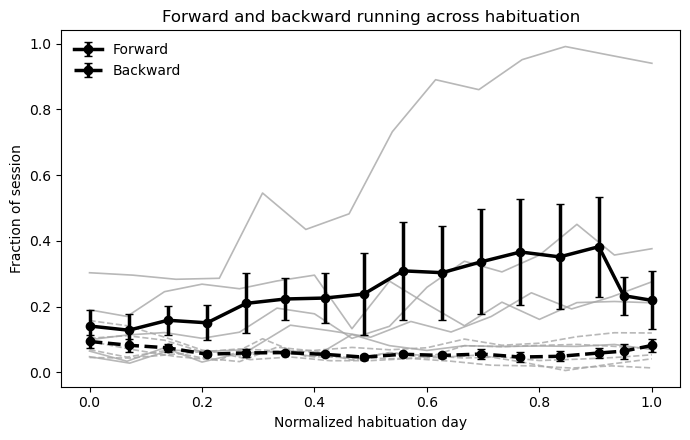

In [3]:
from src.vis.plots import plot_habituation_forward_backward

fig, ax, hab_fb_summary = plot_habituation_forward_backward(hab_session_df)

In [4]:
def make_habituation_direction_daybin_df(hab_session_df):
    """
    Make animal × day-bin × direction table for RM-ANOVA.
    """

    daybin_df = (
        hab_session_df
        .groupby(["animal", "phase_day_bin"], dropna=False)
        .agg(
            frac_forward=("frac_forward", "mean"),
            frac_backward=("frac_backward", "mean"),
            frac_stationary=("frac_stationary", "mean"),
            mean_speed_path_cms=("mean_speed_path_cms", "mean"),
            n_sessions=("date", "nunique"),
        )
        .reset_index()
    )

    long_df = daybin_df.melt(
        id_vars=["animal", "phase_day_bin", "n_sessions"],
        value_vars=["frac_forward", "frac_backward"],
        var_name="direction",
        value_name="frac_locomotor_state"
    )

    long_df["direction"] = long_df["direction"].replace({
        "frac_forward": "forward",
        "frac_backward": "backward",
    })

    long_df["phase_day_bin"] = pd.Categorical(
        long_df["phase_day_bin"],
        categories=["early", "middle", "late"],
        ordered=True
    )

    long_df["direction"] = pd.Categorical(
        long_df["direction"],
        categories=["backward", "forward"],
        ordered=True
    )

    return long_df

In [5]:
hab_direction_rm_df = make_habituation_direction_daybin_df(hab_session_df)

hab_direction_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [6]:
from statsmodels.stats.anova import AnovaRM

aov_hab_direction = AnovaRM(
    data=hab_direction_rm_df,
    depvar="frac_locomotor_state",
    subject="animal",
    within=["phase_day_bin", "direction"]
).fit()

print(aov_hab_direction)

                       Anova
                        F Value Num DF Den DF Pr > F
----------------------------------------------------
phase_day_bin            3.1368 2.0000 8.0000 0.0987
direction                3.6664 1.0000 4.0000 0.1280
phase_day_bin:direction  3.0838 2.0000 8.0000 0.1017

